# Cell-driven Niche Perturbation (CNP) Replacement Simulation

This tutorial introduces the Cell-driven Niche Perturbation (CNP) framework for probing how targeted cellular perturbations reshape spatial microenvironments in the aging hippocampus.

We use mouse Stereo-seq data from Ma et al., Cell (2024) to demonstrate how cell-level perturbations can causally link cellular identity to niche organization during aging.

⸻

Dataset

Study
Spatial transcriptomic landscape unveils immunoglobulin-associated senescence as a hallmark of aging
Ma, Shuai et al., Cell, 2024

The dataset captures spatial gene expression patterns in the hippocampus of young (2-month-old) and aged (25-month-old) mice.

⸻

Regions of Interest (ROIs)

Selected hippocampal ROIs from young and aged mice are used as localized spatial contexts to analyze niche-level responses to perturbation.

⸻

CNP Perturbation Modes

1. Cell Replacement

Aged cells within a target niche are replaced by their young counterparts, partially overwriting the aged tissue context.
This mode evaluates how rejuvenated cellular identities reshape surrounding microenvironments.

2. Cell Injection

Young cells are introduced into aged ROIs without removing native aged cells.
This mode isolates how rejuvenating cues propagate through an intact aged structural substrate.

⸻

Evaluation

For both perturbation modes, we assess:
	•	Spatial remodeling within ROIs
	•	Cell- and niche-level embedding similarity to the young reference
	•	Microenvironmental responses across major cell types

⸻

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import anndata as ad
import seaborn as sns
from typing import Optional
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import sys
sys.path.append("/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon_v2/BrainBeacon/")
from brainbeacon.pipeline.cell_embedding import run_bbcellformer_pipeline
from brainbeacon.pipeline.perturbation import inject_cells_theory, inject_cells_into_niche, plot_cosine_to_centroids_non_target, analyze_embedding_similarity_change_similarity_niche
from brainbeacon.pipeline.perturbation import analyze_embedding_similarity_change, analyze_gene_reconstruction_change, compute_delta_cosine
from brainbeacon.utils import set_seed
import brainbeacon.configs.config as cfg
from brainbeacon.configs.config_train import config_train as cfg_train
from brainbeacon.utils import compute_density_token, compute_deviation_bin_rapid_v2
from brainbeacon.utils import convert_spatial_to_um, platform_radius_map
import logging
logging.basicConfig(
    level=logging.INFO,  # 或 level=logging.DEBUG
    format='%(asctime)s %(levelname)s %(message)s'
)

import warnings
plt.rcParams["pdf.fonttype"] = 42
warnings.filterwarnings("ignore")
set_seed(42)

/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set GPU 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

# Define base paths and dataset info
out_fig_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/virtual_perturbation/fig5_subfig"
os.makedirs(out_fig_dir, exist_ok=True)

Using device: cuda
Using GPU: NVIDIA H800


In [ ]:
# =============================================================================
# 1. Dataset and Basic Setup
# =============================================================================
dataset_name = "niche2cell_replacement"
specie = "mouse"  # NOTE: keep original variable name for compatibility
assay = "stereo"

# =============================================================================
# 2. Prior Knowledge / Paths
# =============================================================================
# Base directories
BASE_DIR = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/")

# Sync into cfg (assumes cfg / cfg_train already exist in your notebook/runtime)
cfg.DEFAULT_PATHS["BASE_DIR"] = str(BASE_DIR)
cfg.DEFAULT_PATHS["PRETRAIN_DIR"] = "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/"
cfg.DEFAULT_PATHS["PRIOR_DIR"] = cfg.DEFAULT_PATHS["PRETRAIN_DIR"]
cfg.DEFAULT_PATHS["GENE_DICT_PATH"] = (
    "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/model_h5ad_1211.h5ad"
)

# Input data
# Path to the processed AnnData object used in this tutorial.
# The processed file (adata_outer_ensembl.h5ad) can be downloaded directly from:
# https://drive.google.com/file/d/1-z8J8xiRN0qD0preVQr8cAHKQXuScBp2/view?usp=drive_link
#
# Alternatively, the original raw Stereo-seq data can be obtained from the CNGBdb STOmics portal:
# https://db.cngb.org/stomics/datasets/STDS0000247/data
# Users may start from the raw data and follow their own preprocessing pipeline if desired.
adata_path = BASE_DIR / "data" / "adata_outer_ensembl.h5ad"  # adata_outer_ensembl / adata_inner_ensembl
gene_dict_path = Path(cfg.DEFAULT_PATHS["GENE_DICT_PATH"])
gene_mean_path = Path(
    "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/stereo-seq_gene_nonzero_means_metacell_2.npy"
)

# ESM embedding path
cfg_train["esm_embedding_path"] = (
    "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/esm2_embeddings_d5120.pt"
)

# Basic sanity checks (fail fast)
assert adata_path.exists(), f"adata_path not found: {adata_path}"
assert gene_dict_path.exists(), f"gene_dict_path not found: {gene_dict_path}"
assert gene_mean_path.exists(), f"gene_mean_path not found: {gene_mean_path}"
assert Path(cfg_train["esm_embedding_path"]).exists(), f"esm_embedding_path not found: {cfg_train['esm_embedding_path']}"

# =============================================================================
# 3. Pretrained Checkpoints
# =============================================================================
pretrain_dir = BASE_DIR / "pretrained"

bb_ckpt_name = "epoch_0_setp_800000.pt"
cellformer_ckpt_name = "cellformer_epoch99.pt"  # trained on all ma2024aging data
# cellformer_ckpt_name = "cellformer.ckpt"      # CellPLM original checkpoint

bb_ckpt_path = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt")
cellplm_ckpt_path = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt")

assert bb_ckpt_path.exists(), f"bb_ckpt_path not found: {bb_ckpt_path}"
assert cellplm_ckpt_path.exists(), f"cellplm_ckpt_path not found: {cellplm_ckpt_path}"

# =============================================================================
# 4. Output Naming
# =============================================================================
cd_weight = 0.02
use_hvg = True
n_hvg = 5000

bb_ckpt_tag = bb_ckpt_name.replace(".pt", "").replace(".ckpt", "")
if use_hvg:
    method_name = f"bbcellformer_{bb_ckpt_tag}_hvg{n_hvg}_cd{cd_weight}"
else:
    method_name = f"bbcellformer_{bb_ckpt_tag}_cd{cd_weight}"

output_dir = BASE_DIR / "downstream_tasks" / "virtual_perturbation" / "outputs" / dataset_name / method_name
output_dir.mkdir(parents=True, exist_ok=True)

# =============================================================================
# 5. Load Data and (Optionally) Select Slices
# =============================================================================
full_adata = sc.read_h5ad(str(adata_path))

selected_slices = ["Hippocampus_Y_2_1", "Hippocampus_O_2_1"]

# NOTE: Uncomment if you want to restrict to selected slices
# adata = full_adata[full_adata.obs["slice"].isin(selected_slices)].copy()
adata = full_adata.copy()

# =============================================================================
# 6. Derive Labels
# =============================================================================
def infer_cell_label(slice_name: str) -> Optional[str]:
    """Infer 'Young' / 'Old' from slice naming convention."""
    if slice_name.startswith("Hippocampus_Y"):
        return "Young"
    if slice_name.startswith("Hippocampus_O"):
        return "Old"
    return None  # Unknown slice pattern

# Apply label + batch
adata.obs["cell_label"] = adata.obs["slice"].astype(str).map(infer_cell_label)
adata.obs["batch"] = adata.obs["slice"]

# Enforce categorical type (keeps only 'Young' and 'Old' as known categories)
adata.obs["cell_label"] = pd.Categorical(adata.obs["cell_label"], categories=["Young", "Old"])

Next, we select regions of interest (ROIs) to further investigate
how the perturbation reshapes local cellular niches after gene perturbation.
These ROIs enable a focused analysis of spatial and niche-level changes
induced by the perturbation.

AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'lognorm', 'raw_count'


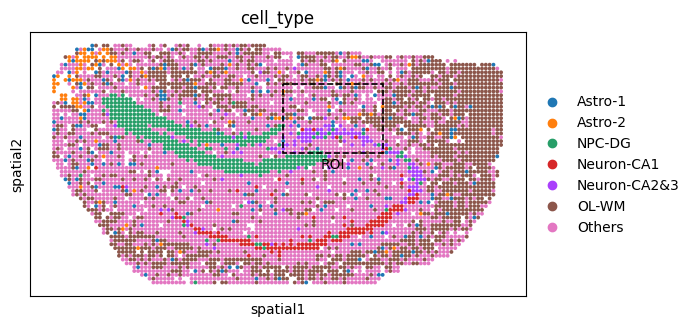

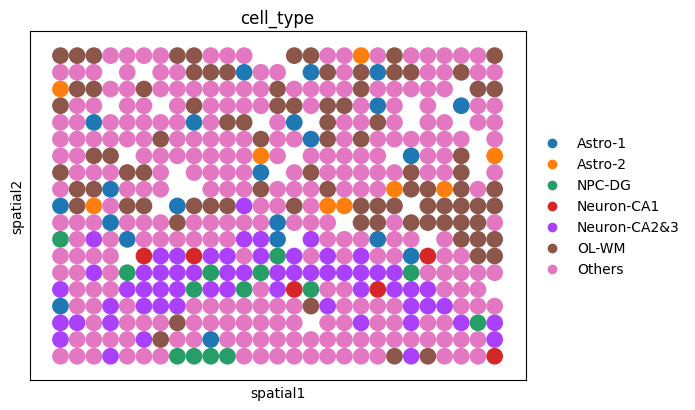

In [4]:
ol_cells = adata[adata.obs["slice"] == "Hippocampus_O_2_1"].copy()
ol_roi = ol_cells[
    (ol_cells.obsm["spatial"][:, 0] > 60) &    
    (ol_cells.obsm["spatial"][:, 1] > 10) &    
    (ol_cells.obsm["spatial"][:, 0] < 88) &      
    (ol_cells.obsm["spatial"][:, 1] < 30)
].copy()
print(ol_roi)
ol_cells.obs["cell_type"] = ol_cells.obs["cell_type"].astype("category")
categories = ol_cells.obs["cell_type"].cat.categories
ol_roi.obs["cell_type"] = pd.Categorical(
    ol_roi.obs["cell_type"], categories=categories, ordered=True
)

ol_cells.uns["cell_type_colors"] = ol_cells.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(categories)]
)
ol_roi.uns["cell_type_colors"] = ol_cells.uns["cell_type_colors"]

roi_coords = ol_roi.obsm["spatial"]
xmin, xmax = roi_coords[:, 0].min(), roi_coords[:, 0].max()
ymin, ymax = roi_coords[:, 1].min(), roi_coords[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2
os.makedirs(out_fig_dir, exist_ok=True)

fig_ol = sc.pl.spatial(
    ol_cells, color="cell_type", spot_size=1, show=False, return_fig=True
)
ax_ol = fig_ol.axes[0]
rect = Rectangle(
    (xmin, ymin), xmax - xmin, ymax - ymin,
    linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--'
)
ax_ol.add_patch(rect)

ax_ol.text(
    xcenter, ymax + 5, "ROI",
    color='black', fontsize=10, ha='center', va='bottom'
)
fig_roi = sc.pl.spatial(
    ol_roi, color="cell_type", spot_size=1, show=False, return_fig=True
)

x: 1.0 ~ 85.0, y: 1.0 ~ 52.0
ROI cells: 495


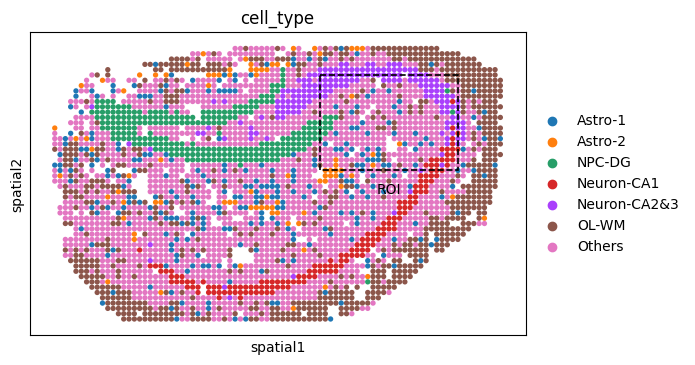

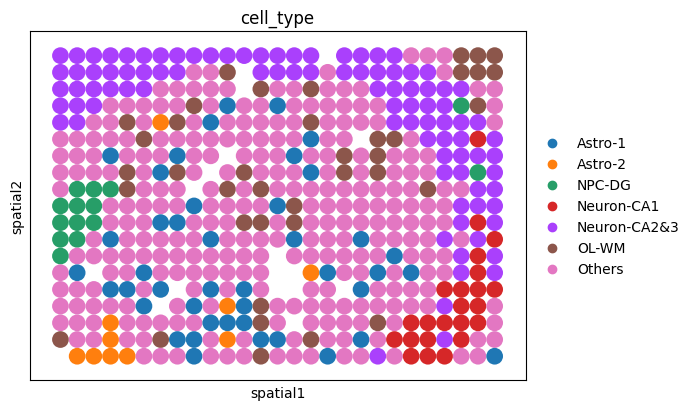

In [5]:
# === Matplotlib settings (ensure editable text in PDF/SVG) ===
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

# === Ensure output directory ===
os.makedirs(out_fig_dir, exist_ok=True)

# === Step 1: subset slice ===
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1"].copy()

# === Step 2: coordinates ===
x = adata_Y.obsm["spatial"][:, 0]
y = adata_Y.obsm["spatial"][:, 1]
print(f"x: {x.min():.1f} ~ {x.max():.1f}, y: {y.min():.1f} ~ {y.max():.1f}")

# === Step 3: ROI bounds (x in (60, 88), y in (10, 30)) ===
roi_mask = (x > 50) & (x < 78) & (y > 5) & (y < 25)
y_roi = adata_Y[roi_mask].copy()
print(f"ROI cells: {y_roi.n_obs}")

# === Step 4: sync categories & colors ===
adata_Y.obs["cell_type"] = adata_Y.obs["cell_type"].astype("category")
cats = adata_Y.obs["cell_type"].cat.categories
y_roi.obs["cell_type"] = pd.Categorical(y_roi.obs["cell_type"], categories=cats, ordered=True)

adata_Y.uns["cell_type_colors"] = adata_Y.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(cats)]
)
y_roi.uns["cell_type_colors"] = adata_Y.uns["cell_type_colors"]

# === Step 5a: full view with ROI box ===
fig1 = sc.pl.spatial(adata_Y, color="cell_type", spot_size=1, show=False, return_fig=True)

# Add dashed ROI box
roi_xy = y_roi.obsm["spatial"]
xmin, xmax = roi_xy[:, 0].min(), roi_xy[:, 0].max()
ymin, ymax = roi_xy[:, 1].min(), roi_xy[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2

ax = fig1.axes[0]
rect = Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                 linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(xcenter, ymax + 5, "ROI", color='black', fontsize=10, ha='center', va='bottom')
# === Step 5b: ROI-only ===
fig2 = sc.pl.spatial(y_roi, color="cell_type", spot_size=1, show=False, return_fig=True)

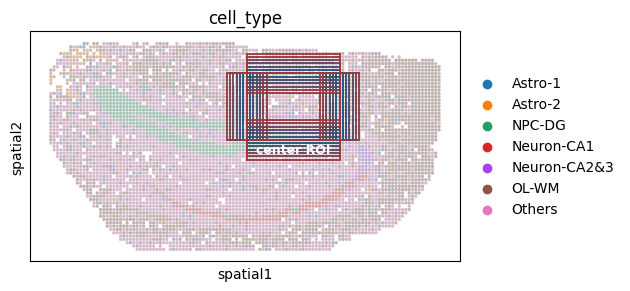

In [6]:
fig_ol = sc.pl.spatial(
    ol_cells,
    color="cell_type",
    spot_size=1,
    show=False,
    return_fig=True
)
ax_ol = fig_ol.axes[0]

for c in ax_ol.collections:
    facecolors = c.get_facecolor()
    # Gray
    gray = np.array([0.5, 0.5, 0.5, 1.0])
    mixed = 0.5 * facecolors + 0.5 * gray
    c.set_facecolor(mixed)
    c.set_alpha(0.5)   

# === ROI ===
ol_base_x, ol_base_y = (60, 88), (10, 30)
shifts = [(0, 0), (1, 0), (-1, 0), (0, 1), (0, -1),
           (2, 0), (-2, 0), (0, 2), (0, -2),
           (3, 0), (-3, 0), (0, 3), (0, -3),
           (4, 0), (-4, 0), (0, 4), (0, -4),
           (5, 0), (-5, 0), (0, 5), (0, -5),
           (6, 0), (-6, 0), (0, 6), (0, -6)]

import matplotlib.colors as mcolors
start_color = "#145583" 
end_color   = "#A13939" 
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", [start_color, end_color])
colors = [cmap(i / (len(shifts)-1)) for i in range(len(shifts))]

# ===  ROI box===
for i, (dx, dy) in enumerate(shifts):
    xmin, xmax = ol_base_x[0] + dx, ol_base_x[1] + dx
    ymin, ymax = ol_base_y[0] + dy, ol_base_y[1] + dy
    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=1.4,
        edgecolor=colors[i],
        facecolor='none',
        linestyle='-',
        alpha=0.95,
    )
    ax_ol.add_patch(rect)

# ===  ROI anno ===
ax_ol.text(
    np.mean(ol_base_x),
    ol_base_y[1] + 5,
    "center ROI",
    color='white',
    fontsize=9,
    weight='bold',
    ha='center',
    va='bottom'
)

plt.tight_layout()
# plt.savefig(f"{out_fig_dir}/ol_cells_with_multiple_roi_boxes.pdf", bbox_inches="tight")
plt.show()

In [7]:
ol_roi.obs["brain_region"] = ol_roi.obs["slice"]
ol_roi.obs["brain_region_main"] = ol_roi.obs["slice"]
ol_roi.obsm["spatial"] = ol_roi.obsm["spatial"].astype(np.float32)
ol_roi = compute_deviation_bin_rapid_v2(ol_roi)
ol_roi = convert_spatial_to_um(ol_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
ol_roi, _ = compute_density_token(ol_roi, radius)

y_roi.obs["brain_region"] = y_roi.obs["slice"]
y_roi.obs["brain_region_main"] = y_roi.obs["slice"]
y_roi.obsm["spatial"] = y_roi.obsm["spatial"].astype(np.float32)
y_roi = compute_deviation_bin_rapid_v2(y_roi)
y_roi = convert_spatial_to_um(y_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
y_roi, _ = compute_density_token(y_roi, radius)

In [8]:
adata_fov_OL = ad.concat([ol_roi, y_roi], join="outer")
adata_fov_OL.var = adata.var.loc[adata_fov_OL.var_names].copy()
output_prefix_ori = "original"
adata_fov_OL.obs["split"] = "train"
os.makedirs(output_dir, exist_ok=True)
ori_input_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_input.h5ad")
adata_fov_OL.write(ori_input_adata_path)
print(f"Saved selected slices to: {ori_input_adata_path}")

... storing 'slice_brain_area' as categorical
... storing 'split' as categorical


Saved selected slices to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad


In [9]:
print(ol_roi)
print(y_roi)
print(adata)
print(adata_fov_OL)

AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slice_brain_area', 'density_token'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    uns: 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'deviation_bin', 'neighbor_gene_distribution', 'spatial_um'
    layers: 'lognorm', 'raw_count'
AnnData object with n_obs × n_vars = 495 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_i

In [10]:
# ========== Run Original Inference ==========
# This step constructs the baseline (unperturbed) reference by running inference
# on the original data, which serves as the control condition for all subsequent
# perturbation analyses.
adata_ori = run_bbcellformer_pipeline(
    adata_path=ori_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_ori,
    config_train=cfg_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    weight_mode="expression",
    use_batch=False,
    use_spatial=True,
    force_tokenize=True,
    do_fit=True,  # recommended to set to True for original reconstruction
    device=device,
    fit_epochs=100,
)
print("Original reconstruction complete. Embeddings and model saved.")
print("adata_ori:", adata_ori)

ori_result_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_result.h5ad")
adata_ori.write(ori_result_adata_path)
print(f"Original result adata saved to: {ori_result_adata_path}")


Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...
compute_density_token time:  0.0038668354352315265 min


Processing data batches: 100%|██████████| 1/1 [00:04<00:00,  4.28s/it]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.12 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:11<00:00,  1.35it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
Time cost:  0.31237366994222004
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20316 genes remain.


...

Epoch 98 | Train loss: 6803.6355 | Valid loss: 6843.8608


100%|██████████| 100/100 [01:00<00:00,  1.66it/s]

Epoch 99 | Train loss: 6832.2544 | Valid loss: 6840.0640
After filtering, 20316 genes remain.



... storing 'platform' as categorical
... storing 'valid_split' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_embeddings.npz
Original reconstruction complete. Embeddings and model saved.
adata_ori: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', '

In [11]:
# ========== CNP Perturbation (Replacement): Young NPC-DG cells replace aged NPC-DG in situ ==========
# This block implements the "replacement" mode in the Cell-driven Niche Perturbation (CNP) framework.
#
# Using NPC-DG as an example, aged NPC-DG cells in the old hippocampal slice are
# in situ replaced by their young counterparts sampled from the young slice.
#
# This operation preserves the surrounding aged tissue context while overwriting
# the cellular identity of the target cell type, enabling evaluation of how
# rejuvenated cells remodel local niches.
#
# Downstream analyses quantify niche-level changes using four metrics:
# cosine similarity, Euclidean distance, Wasserstein distance (EMD), and MMD.
celltype = "NPC-DG"
SLICE_YOUNG = "Hippocampus_Y_2_1"
SLICE_OLD = "Hippocampus_O_2_1"
old_slice  = adata_fov_OL[adata_fov_OL.obs["slice"] == SLICE_OLD]
young_pool = adata_fov_OL[adata_fov_OL.obs["slice"] == SLICE_YOUNG]

perturbed_adata = inject_cells_theory(
    target_adata = old_slice,
    donor_adata  = young_pool,
    celltype     = celltype,
    spatial_key  = "spatial",
    random_state = 4
)
pert_input = ad.concat(
    [perturbed_adata, adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_Y_2_1"]],
    join="outer"
)
output_prefix_perturb = "inject_young_NPC-DG_to_old"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
pert_input.write(perturb_input_adata_path)
print(f"Injected input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=cfg_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=False,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb.write(perturb_result_adata_path)
print(f"Perturbation result adat2a saved to: {perturb_result_adata_path}")
adata_injected_celltype = adata_perturb[adata_perturb.obs["injected"].notna()].copy()
adata_injected_celltype.obs["injected"] = adata_injected_celltype.obs["injected"].astype(bool)
adata_perturb_sub = adata_injected_celltype[~adata_injected_celltype.obs["injected"]].copy()

... storing 'cell_type' as categorical
... storing 'injected_celltype' as categorical


Injected input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...
compute_density_token time:  0.0039066950480143225 min


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.04 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:10<00:00,  1.49it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_bb_embeddings.npz
Time cost:  0.28074302673339846
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20316 gen

... storing 'platform' as categorical
... storing 'valid_split' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_replacement/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_embeddings.npz
Perturbation reconstruction complete. Embeddings and model saved.
adata_perturb: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'ba

In [12]:
# =============================================================================
# Niche-level similarity analysis after CNP replacement
# =============================================================================
# We quantify how the replacement perturbation shifts the aged niche
# toward the young reference state for the target cell type (NPC-DG).

replacement_niche_result = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_sub,
    target_slice_young=SLICE_YOUNG,
    target_slice_old=SLICE_OLD,
    target_celltype="NPC-DG",
    embedding_key="X_emb",
)

# Unpack similarity metrics (before vs after replacement)
cosine_before_rep, cosine_after_rep = replacement_niche_result["cosine"]
euclid_before_rep, euclid_after_rep = replacement_niche_result["euclidean"]
emd_before_rep, emd_after_rep = replacement_niche_result["emd"]
mmd_before_rep, mmd_after_rep = replacement_niche_result["mmd"]

print("CNP replacement (NPC-DG) — niche similarity to young reference:")
print("  Cosine similarity        : before = {:.4f}, after = {:.4f}".format(cosine_before_rep, cosine_after_rep))
print("  Euclidean distance       : before = {:.4f}, after = {:.4f}".format(euclid_before_rep, euclid_after_rep))
print("  Wasserstein distance (EMD): before = {:.4f}, after = {:.4f}".format(emd_before_rep, emd_after_rep))
print("  MMD                      : before = {:.4f}, after = {:.4f}".format(mmd_before_rep, mmd_after_rep))

CNP replacement (NPC-DG) — niche similarity to young reference:
  Cosine similarity        : before = 0.1176, after = 0.1345
  Euclidean distance       : before = 12.8969, after = 12.7644
  Wasserstein distance (EMD): before = 0.3651, after = 0.3609
  MMD                      : before = 0.0043, after = 0.0043


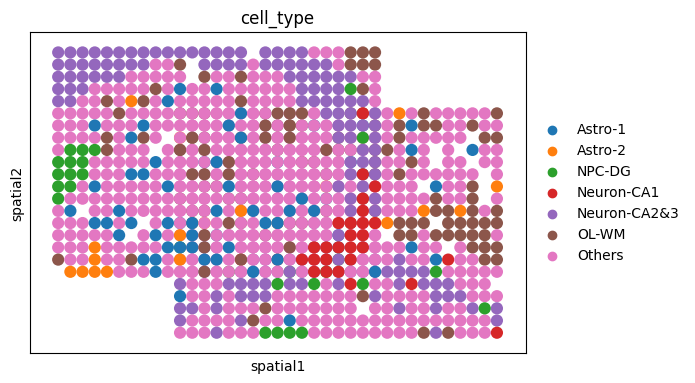

In [13]:
sc.pl.spatial(adata_perturb, color="cell_type", spot_size=1)

In [14]:
adata_injected_celltype = adata_perturb[adata_perturb.obs["injected"].notna()].copy()
adata_injected_celltype.obs["injected"] = adata_injected_celltype.obs["injected"].astype(bool)
adata_perturb_sub = adata_injected_celltype[~adata_injected_celltype.obs["injected"]].copy()
SLICE_OLD   = "Hippocampus_O_2_1"
SLICE_YOUNG = "Hippocampus_Y_2_1"

In [15]:
adata_perturb.obs["injected"]

61_11-Hippocampus_O_2_1    False
61_12-Hippocampus_O_2_1    False
61_13-Hippocampus_O_2_1    False
61_14-Hippocampus_O_2_1    False
61_15-Hippocampus_O_2_1    False
                           ...  
77_24-Hippocampus_Y_2_1     <NA>
77_6-Hippocampus_Y_2_1      <NA>
77_7-Hippocampus_Y_2_1      <NA>
77_8-Hippocampus_Y_2_1      <NA>
77_9-Hippocampus_Y_2_1      <NA>
Name: injected, Length: 976, dtype: boolean

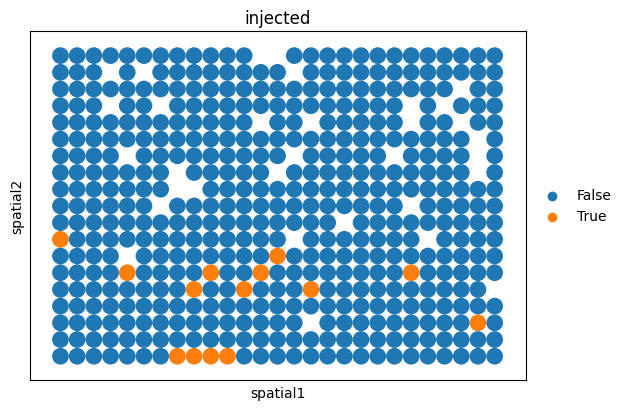

In [16]:
sc.pl.spatial(adata_injected_celltype, color="injected", spot_size=1)

In [17]:
adata_perturb_sub.obs["injected"]

61_11-Hippocampus_O_2_1    False
61_12-Hippocampus_O_2_1    False
61_13-Hippocampus_O_2_1    False
61_14-Hippocampus_O_2_1    False
61_15-Hippocampus_O_2_1    False
                           ...  
87_24-Hippocampus_O_2_1    False
87_26-Hippocampus_O_2_1    False
87_27-Hippocampus_O_2_1    False
87_28-Hippocampus_O_2_1    False
87_29-Hippocampus_O_2_1    False
Name: injected, Length: 467, dtype: bool

[INFO] Excluding target cell type: NPC-DG
[INFO] Remaining cells - Young: 481, Old: 467, Perturb: 467


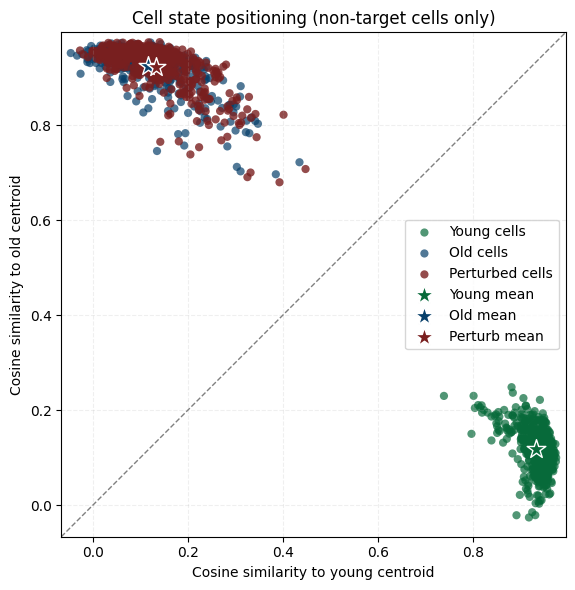

In [18]:
plot_cosine_to_centroids_non_target(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_sub,
    slice_young=SLICE_YOUNG,
    slice_old=SLICE_OLD, 
    target_cell="NPC-DG",
    emb_key="X_emb",
    # save_path="cosine_scatter_theory.pdf"
)

In [19]:
def analyze_inject_gene_reconstruction_change(
    adata_ori_result,
    adata_perturb_result,
    target_cell=None,             # Optional: cell type to exclude from analysis
    target_obs_names=None,
    filter_by=None,
    top_n=100,
    sort_abs=True,
    recon_key="X_pred",
    celltype_key="cell_type"      # Cell type field name in adata.obs
):
    """
    Compare reconstructed gene expression between original and perturbed AnnData objects.

    This function computes gene-wise changes in reconstructed expression (e.g., decoder output)
    between original and perturbed states, optionally excluding a specific target cell type
    (e.g., injected or replaced cells) to focus on indirect or non-cell-autonomous effects.
    """

    # ===== Step 0: Exclude target cell type if specified =====
    if target_cell is not None:
        mask_ori = adata_ori_result.obs[celltype_key] != target_cell
        mask_perturb = adata_perturb_result.obs[celltype_key] != target_cell

        adata_ori_result = adata_ori_result[mask_ori].copy()
        adata_perturb_result = adata_perturb_result[mask_perturb].copy()

        print(f"[INFO] Excluding target cell type: {target_cell}")
        print(
            f"[INFO] Remaining cells: "
            f"{adata_ori_result.n_obs} (original), "
            f"{adata_perturb_result.n_obs} (perturbed)"
        )

    # ===== Step 1: Select target cells (obs_names) =====
    if target_obs_names is not None:
        selected_obs_names = pd.Index(target_obs_names)
    elif filter_by is not None:
        mask = np.ones(len(adata_perturb_result), dtype=bool)
        for key, val in filter_by.items():
            mask &= (adata_perturb_result.obs[key] == val).values
        selected_obs_names = adata_perturb_result.obs_names[mask]
    else:
        raise ValueError("You must specify either `target_obs_names` or `filter_by`.")

    # ===== Step 2: Ensure shared cells between original and perturbed data =====
    selected_obs_names = selected_obs_names[
        selected_obs_names.isin(adata_ori_result.obs_names)
        & selected_obs_names.isin(adata_perturb_result.obs_names)
    ]

    if len(selected_obs_names) == 0:
        raise ValueError("No matching obs_names found in both AnnData objects after filtering.")

    # ===== Step 3: Retrieve reconstructed expression matrices =====
    obs_idx = adata_ori_result.obs_names.get_indexer(selected_obs_names)
    X_ori = adata_ori_result.obsm[recon_key][obs_idx]
    X_perturb = adata_perturb_result.obsm[recon_key][obs_idx]

    # ===== Step 4: Compute gene-wise mean expression and perturbation delta =====
    mean_ori = X_ori.mean(axis=0)
    mean_perturb = X_perturb.mean(axis=0)
    delta = mean_perturb - mean_ori

    # ===== Step 5: Assemble results table =====
    df = pd.DataFrame({
        "gene_id": adata_ori_result.var_names,
        "gene_symbol": adata_ori_result.var["gene_symbol"].values,
        "ori_mean_expr": mean_ori,
        "perturb_mean_expr": mean_perturb,
        "delta_expr": delta,
        "abs_delta": np.abs(delta),
    })

    # Rank genes by absolute or signed change
    df_sorted = (
        df.sort_values("abs_delta", ascending=False).head(top_n)
        if sort_abs
        else df.sort_values("delta_expr", ascending=False).head(top_n)
    )

    return df_sorted

[INFO] Excluding target cell type: NPC-DG
[INFO] Remaining cells: 948 (original), 467 (perturbed)
                  gene_id gene_symbol  ori_mean_expr  perturb_mean_expr  \
13161  ENSMUSG00000053310        Nrgn       0.587867           0.590324   
4829   ENSMUSG00000060962        Dmkn       0.600472           0.598147   
9538   ENSMUSG00000031517       Gpm6a       0.438859           0.440233   
11551  ENSMUSG00000022587        Ly6e       0.479227           0.480565   
11148  ENSMUSG00000027270       Lamp5       0.445860           0.446925   
4232   ENSMUSG00000027447        Cst3       0.190023           0.191034   
10587  ENSMUSG00000001504        Irx2       0.194393           0.193402   
15191  ENSMUSG00000027347     Rasgrp1       0.361396           0.362378   
11682  ENSMUSG00000052727       Map1b       0.411003           0.411949   
4073   ENSMUSG00000033615       Cplx1       0.417111           0.418057   

       delta_expr  abs_delta  
13161    0.002457   0.002457  
4829    -0.002

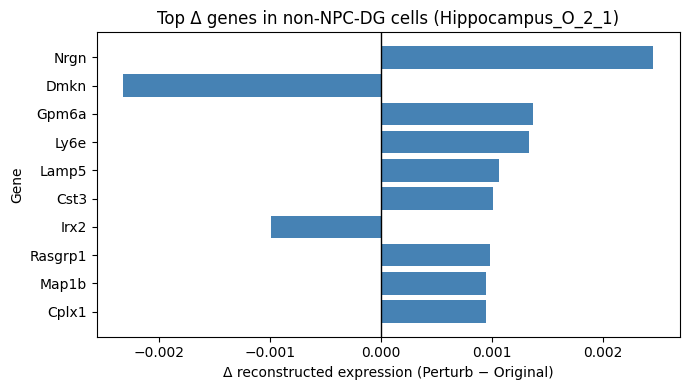

In [20]:
# ===== Select a cell type and slice for analysis =====
target_celltype = "NPC-DG"    # example target cell type
target_slice = SLICE_OLD     # focus on the Old slice only

# ===== Run gene reconstruction change analysis =====
df_delta = analyze_inject_gene_reconstruction_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_sub,
    target_cell="NPC-DG",                 # cell type to EXCLUDE from analysis
    filter_by={"slice": target_slice},    # restrict analysis to the selected slice
    top_n=10,
)

# Print the resulting table
print(df_delta)

# ===== Visualization (bar plot) =====
# Visualize gene-wise changes in reconstructed expression
# after injection-based perturbation, excluding the target cell type.

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.barh(df_delta["gene_symbol"], df_delta["delta_expr"], color="steelblue")
plt.axvline(0, color="black", lw=1)
plt.xlabel("Δ reconstructed expression (Perturb − Original)")
plt.ylabel("Gene")
plt.title(f"Top Δ genes in non-{target_celltype} cells ({target_slice})")
plt.gca().invert_yaxis()  # show top-ranked genes at the top
plt.tight_layout()
plt.show()

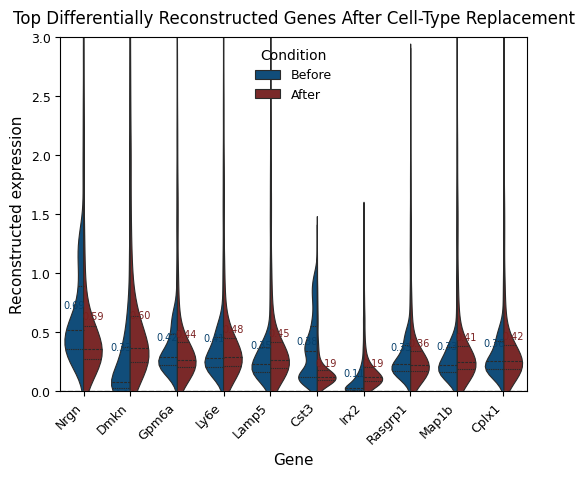

In [21]:
# ===== Select top genes by reconstruction change (|Δ|), top 20 =====
top_genes = (
    df_delta.sort_values("abs_delta", ascending=False)
    .head(20)["gene_symbol"]
    .tolist()
)

# Retrieve reconstructed expression matrices
X_ori = adata_ori.obsm["X_pred"]
X_perturb = adata_perturb_sub.obsm["X_pred"]

# Select indices of top genes
gene_idx = adata_ori.var["gene_symbol"].isin(top_genes)

expr_ori = X_ori[:, gene_idx]
expr_perturb = X_perturb[:, gene_idx]

# ===== Build plotting DataFrame =====
df_plot = pd.DataFrame(expr_ori, columns=adata_ori.var["gene_symbol"][gene_idx])
df_plot = df_plot.melt(var_name="gene_symbol", value_name="expr")
df_plot["condition"] = "Before"

df_plot2 = pd.DataFrame(expr_perturb, columns=adata_ori.var["gene_symbol"][gene_idx])
df_plot2 = df_plot2.melt(var_name="gene_symbol", value_name="expr")
df_plot2["condition"] = "After"

df_plot = pd.concat([df_plot, df_plot2], ignore_index=True)

# Ensure gene order follows Δ ranking
df_plot["gene_symbol"] = pd.Categorical(
    df_plot["gene_symbol"],
    categories=top_genes,
    ordered=True,
)

# ===== Violin plot =====
plt.figure(figsize=(5.5, 4.8))  # compact x-axis layout
sns.violinplot(
    data=df_plot,
    x="gene_symbol",
    y="expr",
    hue="condition",
    split=True,
    inner="quartile",
    palette={"Before": "#004f8bff", "After": "#871b1bff"},
    linewidth=0.8,
    scale="width",  # uniform violin width
)

# ===== Annotate mean expression values =====
means = (
    df_plot.groupby(["gene_symbol", "condition"])["expr"]
    .mean()
    .reset_index()
)

for i, gene in enumerate(top_genes):
    for cond, color in zip(
        ["Before", "After"],
        ["#073f6aff", "#791f1fff"],
    ):
        mean_val = means.query(
            "gene_symbol == @gene and condition == @cond"
        )["expr"].values[0]
        x_offset = -0.2 if cond == "Before" else 0.2
        plt.text(
            i + x_offset,
            mean_val,
            f"{mean_val:.2f}",
            color=color,
            ha="center",
            va="bottom",
            fontsize=7,
        )

# ===== Axis and style adjustments =====
plt.ylim(0, 3)  # fix y-axis range
plt.axhline(0, ls="--", c="gray", lw=1)
plt.xlabel("Gene", fontsize=11)
plt.ylabel("Reconstructed expression", fontsize=11)
plt.title(
    "Top Differentially Reconstructed Genes After Cell-Type Replacement",
    fontsize=12,
    pad=10,
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.legend(
    title="Condition",
    fontsize=9,
    title_fontsize=10,
    frameon=False,
)

plt.tight_layout(pad=0.8, rect=[0.02, 0, 1, 1])
plt.show()
# plt.savefig(
#     "violin_rec_exp_by_injected_theory2.pdf",
#     bbox_inches="tight",
#     dpi=300,
# )

In [22]:
aging_genes = {
    "Bc1","Tlk1","Meg3","Ppm1e","Tmsb4x","Stmn3","Rtn1",
    "Prkca","Snhg11","Fth1"
}


Found aging genes: ['Ppm1e', 'Tmsb4x', 'Tlk1', 'Fth1', 'Rtn1', 'Prkca', 'Bc1', 'Meg3', 'Stmn3', 'Snhg11']


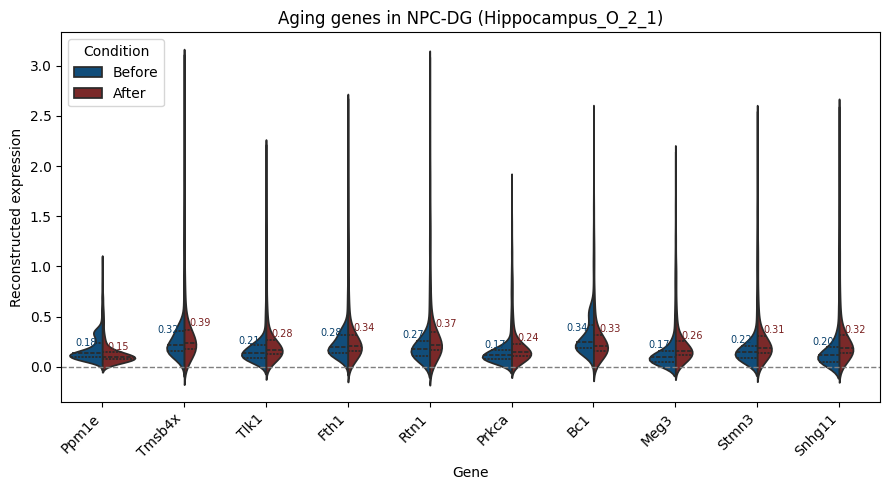

In [23]:
# This block inspects reconstructed expression changes for a predefined set of
# genes of interest (aging-associated genes). By focusing on this curated gene set,
# the visualization highlights how biologically relevant aging markers respond
# to the perturbation in a targeted and interpretable manner.

# ==== Aging gene set ====
aging_genes = {
    "Bc1", "Tlk1", "Meg3", "Ppm1e", "Tmsb4x", "Stmn3", "Rtn1",
    "Prkca", "Snhg11", "Fth1",
}

# Retain only genes that are present in the current dataset
aging_genes_in_data = [
    g for g in aging_genes
    if g in adata_ori.var["gene_symbol"].values
]
print("Found aging genes:", aging_genes_in_data)

# ==== Retrieve reconstructed expression before and after perturbation ====
X_ori = adata_ori.obsm["X_pred"]
X_perturb = adata_perturb_sub.obsm["X_pred"]

# Select aging-associated genes
gene_idx = adata_ori.var["gene_symbol"].isin(aging_genes_in_data)

expr_ori = X_ori[:, gene_idx]
expr_perturb = X_perturb[:, gene_idx]

# ==== Build plotting DataFrame ====
df_plot = pd.DataFrame(
    expr_ori,
    columns=adata_ori.var["gene_symbol"][gene_idx],
)
df_plot = df_plot.melt(
    var_name="gene_symbol",
    value_name="expr",
)
df_plot["condition"] = "Before"

df_plot2 = pd.DataFrame(
    expr_perturb,
    columns=adata_ori.var["gene_symbol"][gene_idx],
)
df_plot2 = df_plot2.melt(
    var_name="gene_symbol",
    value_name="expr",
)
df_plot2["condition"] = "After"

df_plot = pd.concat([df_plot, df_plot2], ignore_index=True)

# Ensure gene order follows the predefined aging gene list
df_plot["gene_symbol"] = pd.Categorical(
    df_plot["gene_symbol"],
    categories=aging_genes_in_data,
    ordered=True,
)

# ==== Violin plot ====
plt.figure(figsize=(9, 5))
sns.violinplot(
    data=df_plot,
    x="gene_symbol",
    y="expr",
    hue="condition",
    split=True,
    inner="quartile",
    palette={"Before": "#004f8bff", "After": "#871b1bff"},
)

# Annotate mean expression values
means = (
    df_plot.groupby(["gene_symbol", "condition"])["expr"]
    .mean()
    .reset_index()
)
for i, gene in enumerate(aging_genes_in_data):
    for cond, color in zip(
        ["Before", "After"],
        ["#073f6aff", "#791f1fff"],
    ):
        mean_val = means.query(
            "gene_symbol == @gene and condition == @cond"
        )["expr"].values[0]
        x_offset = -0.2 if cond == "Before" else 0.2
        plt.text(
            i + x_offset,
            mean_val,
            f"{mean_val:.2f}",
            color=color,
            ha="center",
            va="bottom",
            fontsize=7,
        )

plt.axhline(0, ls="--", c="gray", lw=1)
plt.xlabel("Gene")
plt.ylabel("Reconstructed expression")
plt.title(f"Aging genes in {target_celltype} ({target_slice})")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()